# Geometry of Embedding Spaces for Multilingual Low-Resource NLP with Marwari and Hindi

**Mini Research Notebook**  
This notebook unifies mathematical foundations, implementation, and experiments to study embedding geometry for low-resource multilingual NLP.  
Frameworks: TensorFlow/Keras, NumPy, pandas, matplotlib, scikit-learn.

## 1. Introduction

Let a token $w$ be represented by a vector $\mathbf{e}_w \in \mathbb{R}^d$. An embedding space is a geometric space in which semantic and syntactic relations are encoded through vector proximity, direction, and curvature-aware distance.

For multilingual low-resource NLP, we seek mappings between languages with unequal data availability. Hindi has richer resources than Marwari, while Marwari suffers from sparsity, lexical variation, and noisy orthography. A geometric approach allows us to compare and align their latent spaces under multiple metrics:

- Euclidean geometry ($K=0$)
- Spherical/angular geometry ($K>0$ intuition on normalized vectors)
- Hyperbolic geometry ($K<0$), useful for hierarchical organization

Goal: learn monolingual embeddings, align Marwari to Hindi, and analyze geometric behavior (including isotropy/anisotropy) in a reproducible research prototype.

## 2. Mathematical Foundations

Given vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$:

1. **Euclidean distance**
$$
d_E(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|_2 = \sqrt{\sum_{i=1}^d (x_i - y_i)^2}
$$

2. **Cosine similarity**
$$
\mathrm{cos}(\mathbf{x}, \mathbf{y}) = \frac{\mathbf{x}^\top \mathbf{y}}{\|\mathbf{x}\|_2\|\mathbf{y}\|_2}
$$

3. **Angular distance** (geodesic on the unit sphere)
$$
d_{\angle}(\mathbf{x}, \mathbf{y}) = \arccos(\mathrm{cos}(\mathbf{x}, \mathbf{y}))
$$
If vectors are normalized, cosine is exactly the dot product.

4. **Hyperbolic distance** (Poincare ball $\mathbb{B}^d = \{\mathbf{u}: \|\mathbf{u}\|<1\}$)
$$
d_{\mathbb{B}}(\mathbf{u}, \mathbf{v}) = \operatorname{arcosh}\left(1 + \frac{2\|\mathbf{u}-\mathbf{v}\|_2^2}{(1-\|\mathbf{u}\|_2^2)(1-\|\mathbf{v}\|_2^2)}\right)
$$

5. **Manifold hypothesis**
Natural language data in high-dimensional ambient space often lies near a lower-dimensional manifold. Different geometries approximate different manifold structures.

6. **Curvature intuition**
- Positive curvature: spherical geometry, finite volume growth.
- Zero curvature: Euclidean geometry, polynomial volume growth.
- Negative curvature: hyperbolic geometry, exponential volume growth, ideal for trees/hierarchies.

7. **Why anisotropy matters**
If embeddings collapse into a few dominant directions, nearest-neighbor retrieval becomes biased and less discriminative. We diagnose this with mean vectors, directional variance, and singular spectra.

In [39]:
# Core imports and reproducibility
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
import nltk

from tensorflow.keras import layers, Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')

# Force Devanagari-capable font first; keep broad fallback list.
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nirmala UI', 'Mangal', 'Noto Sans Devanagari', 'Arial Unicode MS', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

print('TensorFlow version:', tf.__version__)
print('Matplotlib font preference set to Nirmala UI for Devanagari support.')

TensorFlow version: 2.16.1
Matplotlib font preference set to Nirmala UI for Devanagari support.


## 3. Data Preparation

We use pre-existing corpora (no synthetic generation):

- **English**: NLTK Brown + IEER
- **Hindi**: NLTK Indian corpus (`hindi.pos`)
- **Marwari/Rajasthani**: public ULCA Rajasthani text corpus parquet shard

Pipeline:
- Load corpora from public resources
- Normalize and tokenize text per language
- Keep vocabularies separate with language prefixes (`en_`, `hi_`, `mr_`)
- Generate skip-gram-style positive/negative training pairs

In [40]:
# Real corpus loading: English (Brown+IEER), Hindi (Indian corpus), Marwari (ULCA Rajasthani parquet)
from collections import Counter

nltk.download('brown', quiet=True)
nltk.download('ieer', quiet=True)
nltk.download('indian', quiet=True)

from nltk.corpus import brown, ieer, indian

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\u0900-\u097f\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def sentence_split(text):
    chunks = re.split(r'[\.!?\n]+', text)
    return [c.strip() for c in chunks if c.strip()]

# Keep runtime practical while still using real corpora
N_EN_BROWN = 300
N_EN_IEER = 220
N_HI = 450
N_MR = 450
MAX_VOCAB_PER_LANG = 1200

# English corpus: Brown sentences + IEER raw news text
brown_sents = [' '.join(sent) for sent in brown.sents()[:N_EN_BROWN]]
ieer_raw = ' '.join(ieer.raw(fid) for fid in ieer.fileids())
ieer_sents = sentence_split(normalize_text(ieer_raw))[:N_EN_IEER]
english_corpus = [normalize_text(s) for s in brown_sents] + ieer_sents

# Hindi corpus from Indian corpus
hindi_sents = [' '.join(sent) for sent in indian.sents('hindi.pos')[:N_HI]]
hindi_corpus = [normalize_text(s) for s in hindi_sents]

# Marwari/Rajasthani corpus from public parquet shard
marwari_url = 'https://huggingface.co/datasets/1rsh/tts-rajasthani-ulca/resolve/main/data/train-00000-of-00011.parquet'
mr_df = pd.read_parquet(marwari_url, columns=['text'])
marwari_corpus = [normalize_text(t) for t in mr_df['text'].dropna().astype(str).tolist()[:N_MR]]

def tokenize_corpus(corpus, lang_prefix):
    tok = []
    for sent in corpus:
        words = [w for w in sent.split() if len(w) > 1]
        if words:
            tok.append([f'{lang_prefix}_{w}' for w in words])
    return tok

def cap_vocab(tokenized, max_vocab=1200):
    freq = Counter(w for sent in tokenized for w in sent)
    keep = {w for w, _ in freq.most_common(max_vocab)}
    filtered = [[w for w in sent if w in keep] for sent in tokenized]
    filtered = [sent for sent in filtered if len(sent) >= 3]
    return filtered

def build_vocab(tokenized):
    vocab = sorted(set(tok for sent in tokenized for tok in sent))
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return vocab, word2idx, idx2word

en_tok = cap_vocab(tokenize_corpus(english_corpus, 'en'), max_vocab=MAX_VOCAB_PER_LANG)
hi_tok = cap_vocab(tokenize_corpus(hindi_corpus, 'hi'), max_vocab=MAX_VOCAB_PER_LANG)
mr_tok = cap_vocab(tokenize_corpus(marwari_corpus, 'mr'), max_vocab=MAX_VOCAB_PER_LANG)

en_vocab, en_w2i, en_i2w = build_vocab(en_tok)
hi_vocab, hi_w2i, hi_i2w = build_vocab(hi_tok)
mr_vocab, mr_w2i, mr_i2w = build_vocab(mr_tok)

print('English sentences:', len(en_tok), '| vocab:', len(en_vocab))
print('Hindi sentences  :', len(hi_tok), '| vocab:', len(hi_vocab))
print('Marwari sentences:', len(mr_tok), '| vocab:', len(mr_vocab))
print('Sample English vocab:', en_vocab[:10])
print('Sample Hindi vocab  :', hi_vocab[:10])
print('Sample Marwari vocab:', mr_vocab[:10])

English sentences: 264 | vocab: 1200
Hindi sentences  : 413 | vocab: 1194
Marwari sentences: 449 | vocab: 1200
Sample English vocab: ['en_ability', 'en_able', 'en_about', 'en_above', 'en_according', 'en_account', 'en_accounts', 'en_across', 'en_act', 'en_action']
Sample Hindi vocab  : ['hi_अंतर्राष्ट्रीय', 'hi_अंतिम', 'hi_अकरम', 'hi_अख्तर', 'hi_अगला', 'hi_अगले', 'hi_अगासी', 'hi_अग्रणी', 'hi_अटलबिहारी', 'hi_अतिशयोतिपूर्ण']
Sample Marwari vocab: ['mr_अंतर', 'mr_अंतरिम', 'mr_अंदाज', 'mr_अगुवाई', 'mr_अच्छाई', 'mr_अजमेर', 'mr_अटल', 'mr_अणुव्रत', 'mr_अतिरिक्त', 'mr_अदालत']


In [41]:
def generate_skipgram_pairs(tokenized, word2idx, window_size=2, negatives_per_positive=2, seed=42):
    """Generate (target, context, label) tuples for a simple skip-gram objective."""
    rng = np.random.default_rng(seed)
    vocab_size = len(word2idx)

    positives = []
    for sent in tokenized:
        idxs = [word2idx[w] for w in sent]
        for i, t in enumerate(idxs):
            left = max(0, i - window_size)
            right = min(len(idxs), i + window_size + 1)
            for j in range(left, right):
                if j == i:
                    continue
                positives.append((t, idxs[j], 1))

    positive_set = {(t, c) for t, c, _ in positives}
    samples = positives.copy()

    for t, _, _ in positives:
        for _ in range(negatives_per_positive):
            neg_c = rng.integers(0, vocab_size)
            while (t, int(neg_c)) in positive_set:
                neg_c = rng.integers(0, vocab_size)
            samples.append((t, int(neg_c), 0))

    rng.shuffle(samples)
    target = np.array([s[0] for s in samples], dtype=np.int32)
    context = np.array([s[1] for s in samples], dtype=np.int32)
    labels = np.array([s[2] for s in samples], dtype=np.float32)
    return target, context, labels

en_t, en_c, en_y = generate_skipgram_pairs(en_tok, en_w2i)
hi_t, hi_c, hi_y = generate_skipgram_pairs(hi_tok, hi_w2i)
mr_t, mr_c, mr_y = generate_skipgram_pairs(mr_tok, mr_w2i)

print('English training triples:', en_t.shape[0])
print('Hindi training triples  :', hi_t.shape[0])
print('Marwari training triples:', mr_t.shape[0])

English training triples: 519864
Hindi training triples  : 71010
Marwari training triples: 71982


## 4. Baseline Embeddings (Keras)

We train a compact skip-gram-style model with negative sampling labels. For a target $t$ and context $c$:
$$
p(y=1|t,c) = \sigma(\mathbf{u}_t^\top \mathbf{v}_c)
$$
where $\sigma$ is sigmoid, and $\mathbf{u}_t, \mathbf{v}_c$ are embedding vectors.

In [42]:
def train_skipgram_embedding(vocab_size, target_ids, context_ids, labels, dim=32, epochs=12, lr=1e-2, verbose=0):
    target_in = layers.Input(shape=(1,), dtype='int32', name='target')
    context_in = layers.Input(shape=(1,), dtype='int32', name='context')

    target_emb_layer = layers.Embedding(vocab_size, dim, name='target_embedding')
    context_emb_layer = layers.Embedding(vocab_size, dim, name='context_embedding')

    t_vec = target_emb_layer(target_in)
    c_vec = context_emb_layer(context_in)
    dot = layers.Dot(axes=-1)([t_vec, c_vec])
    dot = layers.Reshape((1,))(dot)
    out = layers.Activation('sigmoid')(dot)

    model = Model(inputs=[target_in, context_in], outputs=out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        [target_ids, context_ids],
        labels,
        batch_size=128,
        epochs=epochs,
        verbose=verbose
    )

    emb = model.get_layer('target_embedding').get_weights()[0]
    return model, emb, history

en_model, en_emb, en_hist = train_skipgram_embedding(len(en_vocab), en_t, en_c, en_y, dim=24, epochs=12)
hi_model, hi_emb, hi_hist = train_skipgram_embedding(len(hi_vocab), hi_t, hi_c, hi_y, dim=24, epochs=12)
mr_model, mr_emb, mr_hist = train_skipgram_embedding(len(mr_vocab), mr_t, mr_c, mr_y, dim=24, epochs=12)

print('English embedding matrix:', en_emb.shape)
print('Hindi embedding matrix  :', hi_emb.shape)
print('Marwari embedding matrix:', mr_emb.shape)
print('Final English loss:', float(en_hist.history['loss'][-1]))
print('Final Hindi loss  :', float(hi_hist.history['loss'][-1]))
print('Final Marwari loss:', float(mr_hist.history['loss'][-1]))

English embedding matrix: (1200, 24)
Hindi embedding matrix  : (1194, 24)
Marwari embedding matrix: (1200, 24)
Final English loss: 0.21081945300102234
Final Hindi loss  : 0.0020246829371899366
Final Marwari loss: 0.002096497919410467


## 5. Geometry Implementations

The following metric functions are the computational core for comparing geometry choices on the same learned embeddings.

In [43]:
EPS = 1e-9

def l2_norm(x, axis=-1, keepdims=False):
    return np.sqrt(np.sum(np.square(x), axis=axis, keepdims=keepdims) + EPS)

def normalize_rows(X):
    return X / l2_norm(X, axis=1, keepdims=True)

def euclidean_distance(x, y):
    return float(l2_norm(x - y))

def cosine_sim(x, y):
    return float(np.dot(x, y) / (l2_norm(x) * l2_norm(y)))

def angular_distance(x, y):
    c = np.clip(cosine_sim(x, y), -1.0, 1.0)
    return float(np.arccos(c))

def project_to_poincare_ball(X, radius=0.95):
    # Smooth projection that preserves direction and keeps points inside unit ball.
    norms = l2_norm(X, axis=1, keepdims=True)
    scaled = np.tanh(norms) * (X / norms)
    return np.clip(scaled, -radius, radius)

def hyperbolic_distance_poincare(u, v):
    u2 = np.sum(u * u)
    v2 = np.sum(v * v)
    diff2 = np.sum((u - v) ** 2)
    denom = (1.0 - u2) * (1.0 - v2)
    denom = max(denom, EPS)
    z = 1.0 + 2.0 * diff2 / denom
    z = max(z, 1.0 + 1e-7)
    return float(np.arccosh(z))

def pairwise_metric_matrix(X, metric='cosine'):
    n = X.shape[0]
    M = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(n):
            if metric == 'euclidean':
                M[i, j] = euclidean_distance(X[i], X[j])
            elif metric == 'cosine':
                M[i, j] = cosine_sim(X[i], X[j])
            elif metric == 'angular':
                M[i, j] = angular_distance(X[i], X[j])
            elif metric == 'hyperbolic':
                M[i, j] = hyperbolic_distance_poincare(X[i], X[j])
            else:
                raise ValueError('Unknown metric')
    return M

In [44]:
# Quick metric sanity check on sample Hindi words
sample_words = hi_vocab[:3]
sample_idx = [hi_w2i[w] for w in sample_words]
X = hi_emb[sample_idx]
X_hyp = project_to_poincare_ball(X)

print('Sample words:', sample_words)
print('Cosine matrix:\n', np.round(pairwise_metric_matrix(X, 'cosine'), 3))
print('Angular matrix:\n', np.round(pairwise_metric_matrix(X, 'angular'), 3))
print('Hyperbolic matrix:\n', np.round(pairwise_metric_matrix(X_hyp, 'hyperbolic'), 3))

Sample words: ['hi_अंतर्राष्ट्रीय', 'hi_अंतिम', 'hi_अकरम']
Cosine matrix:
 [[1.    0.126 0.081]
 [0.126 1.    0.476]
 [0.081 0.476 1.   ]]
Angular matrix:
 [[0.    1.445 1.49 ]
 [1.445 0.    1.075]
 [1.49  1.075 0.   ]]
Hyperbolic matrix:
 [[ 0.    22.525 18.316]
 [22.525  0.    22.156]
 [18.316 22.156  0.   ]]


## 6. Spherical Embeddings

For normalized vectors $\hat{\mathbf{x}} = \mathbf{x}/\|\mathbf{x}\|$, we have:
$$
\hat{\mathbf{x}}^\top \hat{\mathbf{y}} = \cos(\theta)
$$
Thus cosine similarity is the inner product on the unit sphere, and angular distance becomes geodesic length. This eliminates norm magnitude effects and emphasizes direction.

In [45]:
hi_sph = normalize_rows(hi_emb)
mr_sph = normalize_rows(mr_emb)
en_sph = normalize_rows(en_emb)

def compare_cosine_dot(X, idx_a, idx_b):
    x = X[idx_a]
    y = X[idx_b]
    cos_val = cosine_sim(x, y)
    dot_val = float(np.dot(x, y))
    return cos_val, dot_val

wa, wb = hi_vocab[0], hi_vocab[1]
a, b = hi_w2i[wa], hi_w2i[wb]
cos_val, dot_val = compare_cosine_dot(hi_sph, a, b)
print(f'On unit sphere, cosine({wa},{wb}) = {cos_val:.6f}, dot = {dot_val:.6f}')

On unit sphere, cosine(hi_अंतर्राष्ट्रीय,hi_अंतिम) = 0.125720, dot = 0.125720


### Spherical Normalization and Angular Similarity

This visual contrasts pre/post normalization norms and shows the cosine-angle relationship in spherical space.

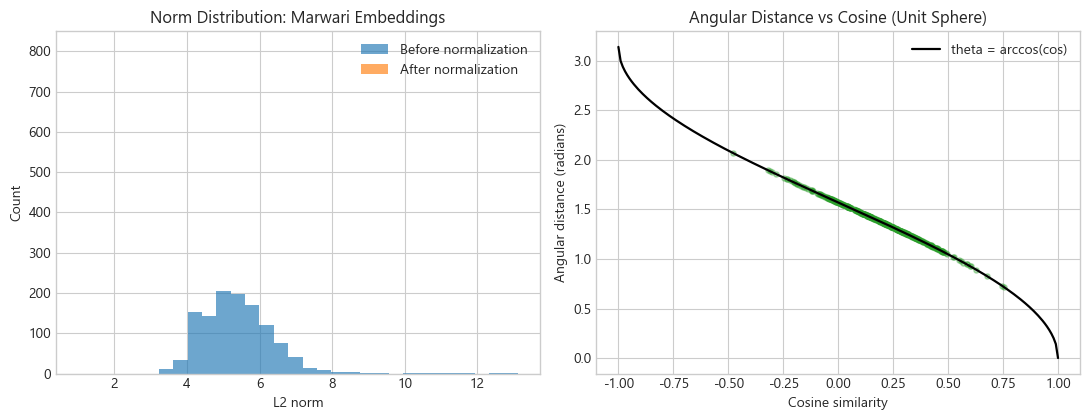

In [78]:
# Visual check: unit-norm behavior and cosine-angle consistency (Marwari)
mr_norm_before = np.linalg.norm(mr_emb, axis=1)
mr_norm_after = np.linalg.norm(mr_sph, axis=1)

# Sample random Marwari pairs to visualize angular relation
rng = np.random.default_rng(42)
n_pairs = min(450, len(mr_vocab) * 2)
idx_a = rng.integers(0, len(mr_vocab), size=n_pairs)
idx_b = rng.integers(0, len(mr_vocab), size=n_pairs)

cos_vals = np.array([cosine_sim(mr_sph[a], mr_sph[b]) for a, b in zip(idx_a, idx_b)])
ang_vals = np.array([angular_distance(mr_sph[a], mr_sph[b]) for a, b in zip(idx_a, idx_b)])

plt.figure(figsize=(11, 4.3))

plt.subplot(1, 2, 1)
plt.hist(mr_norm_before, bins=25, alpha=0.65, label='Before normalization', color='#1f77b4')
plt.hist(mr_norm_after, bins=25, alpha=0.65, label='After normalization', color='#ff7f0e')
plt.title('Norm Distribution: Marwari Embeddings')
plt.xlabel('L2 norm')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(cos_vals, ang_vals, s=14, alpha=0.35, color='#2ca02c')
xline = np.linspace(-1, 1, 200)
plt.plot(xline, np.arccos(np.clip(xline, -1, 1)), color='black', linewidth=1.6, label='theta = arccos(cos)')
plt.title('Angular Distance vs Cosine (Unit Sphere)')
plt.xlabel('Cosine similarity')
plt.ylabel('Angular distance (radians)')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Hyperbolic Embedding Approximation

Hyperbolic spaces naturally represent hierarchies because available volume grows exponentially with radius. Parent-child relations can remain close while siblings spread apart near the boundary.

Toy hierarchy: `animal -> dog -> puppy` and `animal -> bird -> sparrow`. We compare Euclidean and hyperbolic distances from root.

,node,euclidean_from_root,hyperbolic_from_root
0,animal,0.000032,0.000447
1,dog,0.250000,0.510826
2,puppy,0.550364,1.237805
3,bird,0.250000,0.510826
4,sparrow,0.550364,1.237805


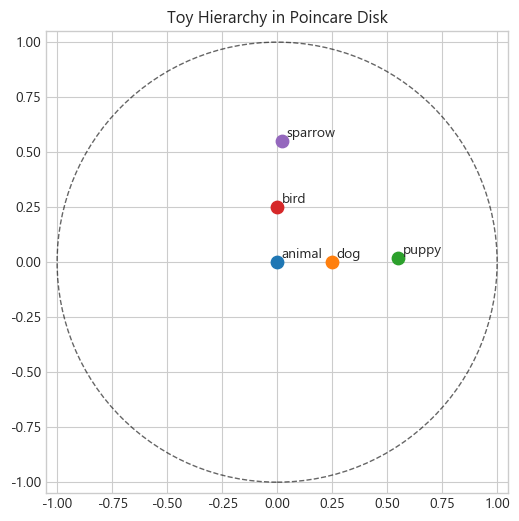

In [47]:
# Toy hierarchical points in 2D, already inside unit disk
toy_nodes = ['animal', 'dog', 'puppy', 'bird', 'sparrow']
toy_xy = np.array([
    [0.00, 0.00],
    [0.25, 0.00],
    [0.55, 0.02],
    [0.00, 0.25],
    [0.02, 0.55],
], dtype=np.float32)

root = toy_xy[0]
rows = []
for i, name in enumerate(toy_nodes):
    d_e = euclidean_distance(root, toy_xy[i])
    d_h = hyperbolic_distance_poincare(root, toy_xy[i])
    rows.append({'node': name, 'euclidean_from_root': d_e, 'hyperbolic_from_root': d_h})

toy_df = pd.DataFrame(rows)
display(toy_df)

plt.figure(figsize=(6, 6))
circle = plt.Circle((0, 0), 1.0, fill=False, linestyle='--', color='black', alpha=0.6)
plt.gca().add_patch(circle)
for i, n in enumerate(toy_nodes):
    plt.scatter(toy_xy[i, 0], toy_xy[i, 1], s=80)
    plt.text(toy_xy[i, 0] + 0.02, toy_xy[i, 1] + 0.02, n)

plt.title('Toy Hierarchy in Poincare Disk')
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.gca().set_aspect('equal', 'box')
plt.show()

## 8. Multilingual Alignment (Marwari ↔ Hindi)

Given paired matrices $X$ (Marwari) and $Y$ (Hindi), Orthogonal Procrustes solves:
$$
W^* = \arg\min_W \|WX - Y\|_F \quad \text{s.t. } W^\top W = I
$$
If $YX^\top = U\Sigma V^\top$, then:
$$
W^* = UV^\top
$$
Orthogonality preserves lengths/angles, reducing distortion during cross-lingual mapping.

### What Is Being Aligned?

We are aligning **embedding coordinate systems**, not raw text directly.

- Source space: Marwari embedding matrix $E_{mr} \in \mathbb{R}^{|V_{mr}| \times d}$
- Target space: Hindi embedding matrix $E_{hi} \in \mathbb{R}^{|V_{hi}| \times d}$
- Anchor dictionary provides paired vectors $(\mathbf{x}_i, \mathbf{y}_i)$ from shared lexical items

Stacking anchor vectors gives:
$$
X = [\mathbf{x}_1,\dots,\mathbf{x}_n] \in \mathbb{R}^{d \times n}, \quad
Y = [\mathbf{y}_1,\dots,\mathbf{y}_n] \in \mathbb{R}^{d \times n}
$$

Orthogonal Procrustes learns a geometry-preserving map $W$ (rotation/reflection):
$$
W^* = \arg\min_{W^\top W=I} \|WX - Y\|_F
$$

Then every Marwari vector is transformed into Hindi coordinates:
$$
\tilde{E}_{mr} = (W E_{mr}^\top)^\top
$$

So the model aligns **vector spaces** so cross-lingual nearest-neighbor comparisons become meaningful.

In [48]:
# Build bilingual seed lexicon from shared surface forms (mr_foo <-> hi_foo)
hi_surface = {w[3:]: w for w in hi_vocab if w.startswith('hi_')}
mr_surface = {w[3:]: w for w in mr_vocab if w.startswith('mr_')}
shared_surface = sorted(set(hi_surface.keys()) & set(mr_surface.keys()))

# Prioritize frequent/common-looking shared tokens
seed_surface = [w for w in shared_surface if len(w) >= 3][:200]
bilingual_pairs = [(mr_surface[w], hi_surface[w]) for w in seed_surface]

# Safety fallback: a few common Devanagari words if overlap is too small
fallback_words = ['भारत', 'सरकार', 'मंत्री', 'देश', 'समय', 'लोग', 'काम', 'नाम', 'कहा', 'है']
if len(bilingual_pairs) < 12:
    for fw in fallback_words:
        m = f'mr_{fw}'
        h = f'hi_{fw}'
        if m in mr_w2i and h in hi_w2i:
            bilingual_pairs.append((m, h))

valid_pairs = [(m, h) for m, h in bilingual_pairs if m in mr_w2i and h in hi_w2i]

X = np.stack([mr_emb[mr_w2i[m]] for m, _ in valid_pairs], axis=1)  # d x n
Y = np.stack([hi_emb[hi_w2i[h]] for _, h in valid_pairs], axis=1)  # d x n

M = Y @ X.T
U, _, Vt = np.linalg.svd(M)
W = U @ Vt

mr_emb_aligned = (W @ mr_emb.T).T

print('Shared surface candidates:', len(shared_surface))
print('Number of alignment pairs:', len(valid_pairs))
print('Orthogonality check ||W^T W - I||_F:', np.linalg.norm(W.T @ W - np.eye(W.shape[0])))

Shared surface candidates: 202
Number of alignment pairs: 170
Orthogonality check ||W^T W - I||_F: 8.305530498290788e-07


In [49]:
def bilingual_pair_cosines(pairs, src_emb, src_w2i, tgt_emb, tgt_w2i):
    rows = []
    for s, t in pairs:
        xs = src_emb[src_w2i[s]]
        yt = tgt_emb[tgt_w2i[t]]
        rows.append({'pair': f'{s}->{t}', 'cosine': cosine_sim(xs, yt)})
    return pd.DataFrame(rows)

before_df = bilingual_pair_cosines(valid_pairs, mr_emb, mr_w2i, hi_emb, hi_w2i)
after_df = bilingual_pair_cosines(valid_pairs, mr_emb_aligned, mr_w2i, hi_emb, hi_w2i)

comparison = before_df.copy()
comparison = comparison.rename(columns={'cosine': 'cosine_before'})
comparison['cosine_after'] = after_df['cosine']
comparison['delta'] = comparison['cosine_after'] - comparison['cosine_before']

display(comparison)
print('Average cosine before:', comparison['cosine_before'].mean())
print('Average cosine after :', comparison['cosine_after'].mean())

,pair,cosine_before,cosine_after,delta
0,mr_अधिकारी->hi_अधिकारी,0.041898,0.365522,0.323624
1,mr_अध्यक्ष->hi_अध्यक्ष,-0.195889,0.480255,0.676144
2,mr_अमेरिका->hi_अमेरिका,0.034873,0.440394,0.405521
3,mr_अलावा->hi_अलावा,-0.048780,0.412773,0.461553
4,mr_अस्पताल->hi_अस्पताल,0.054726,0.401363,0.346637
...,...,...,...,...
165,mr_हरियाणा->hi_हरियाणा,-0.009867,0.510516,0.520384
166,mr_हाथ->hi_हाथ,-0.238572,0.530000,0.768572
167,mr_हालात->hi_हालात,-0.549470,0.110868,0.660338
168,mr_हुई->hi_हुई,0.224685,0.359839,0.135154


Average cosine before: -0.028517758178813617
Average cosine after : 0.4261672049339789


### Orthogonal Procrustes: Marwari -> Hindi

The chart below compares pairwise cosine alignment quality before and after the orthogonal mapping.

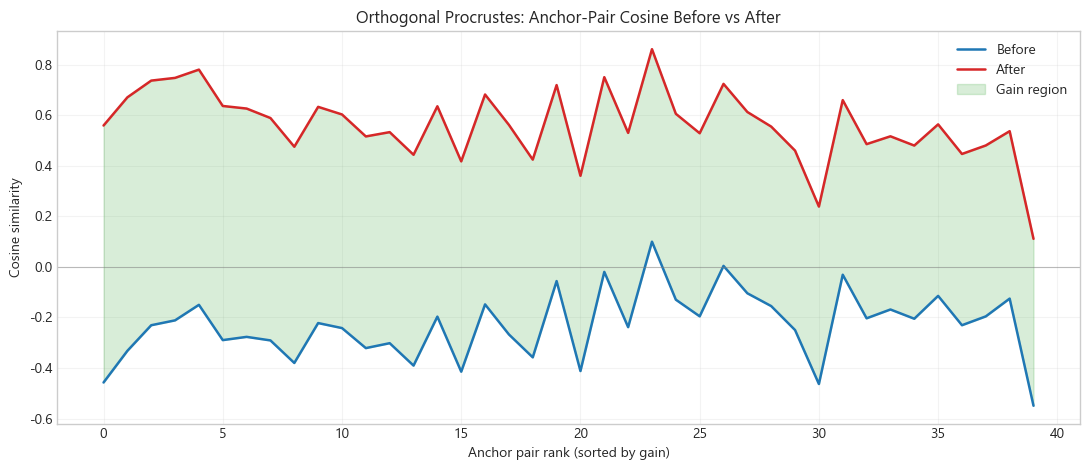

In [50]:
# Visualize pair-wise alignment quality across bilingual anchors
plot_df = comparison.sort_values('delta', ascending=False).reset_index(drop=True)
top_n = min(40, len(plot_df))
plot_df = plot_df.iloc[:top_n]

x = np.arange(top_n)
plt.figure(figsize=(11.0, 4.8))
plt.plot(x, plot_df['cosine_before'], label='Before', color='#1f77b4', linewidth=1.8)
plt.plot(x, plot_df['cosine_after'], label='After', color='#d62728', linewidth=1.8)
plt.fill_between(x, plot_df['cosine_before'], plot_df['cosine_after'], color='#2ca02c', alpha=0.18, label='Gain region')
plt.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
plt.title('Orthogonal Procrustes: Anchor-Pair Cosine Before vs After')
plt.xlabel('Anchor pair rank (sorted by gain)')
plt.ylabel('Cosine similarity')
plt.legend()
plt.grid(alpha=0.22)
plt.tight_layout()
plt.show()

## 9. Isotropy vs Anisotropy Analysis

Let embedding matrix be $E \in \mathbb{R}^{n \times d}$.

- Mean vector: $\boldsymbol{\mu} = \frac{1}{n}\sum_i E_i$
- Centered matrix: $E_c = E - \boldsymbol{\mu}$
- SVD: $E_c = U\Sigma V^\top$

If singular values are highly imbalanced, representations are anisotropic. A practical indicator is:
$$
\mathrm{anisotropy\_ratio} = \frac{\sigma_{\max}}{\frac{1}{d}\sum_j \sigma_j}
$$
Higher ratio implies stronger directional collapse.

In [51]:
def isotropy_statistics(E, n_random_dirs=512, seed=42):
    rng = np.random.default_rng(seed)
    mu = E.mean(axis=0)
    Ec = E - mu

    # Singular spectrum of centered embeddings
    svals = np.linalg.svd(Ec, compute_uv=False)
    anis_ratio = float(svals.max() / (svals.mean() + EPS))

    # Variance of projections on random directions
    dirs = rng.normal(size=(n_random_dirs, E.shape[1]))
    dirs = normalize_rows(dirs)
    proj = Ec @ dirs.T
    var_dirs = proj.var(axis=0)

    return {
        'mean_norm': float(np.linalg.norm(mu)),
        'anisotropy_ratio': anis_ratio,
        'isotropy_index': float(1.0 / (anis_ratio + EPS)),
        'singular_values': svals,
        'directional_variances': var_dirs
    }

stats_en = isotropy_statistics(en_emb)
stats_hi = isotropy_statistics(hi_emb)
stats_mr = isotropy_statistics(mr_emb)
stats_mr_al = isotropy_statistics(mr_emb_aligned)

summary_df = pd.DataFrame([
    {'space': 'Marwari', 'mean_norm': stats_mr['mean_norm'], 'anisotropy_ratio': stats_mr['anisotropy_ratio'], 'isotropy_index': stats_mr['isotropy_index']},
    {'space': 'Marwari Aligned', 'mean_norm': stats_mr_al['mean_norm'], 'anisotropy_ratio': stats_mr_al['anisotropy_ratio'], 'isotropy_index': stats_mr_al['isotropy_index']},
    {'space': 'Hindi', 'mean_norm': stats_hi['mean_norm'], 'anisotropy_ratio': stats_hi['anisotropy_ratio'], 'isotropy_index': stats_hi['isotropy_index']},
    {'space': 'English', 'mean_norm': stats_en['mean_norm'], 'anisotropy_ratio': stats_en['anisotropy_ratio'], 'isotropy_index': stats_en['isotropy_index']},
])

# Difference table against Marwari baseline
mr_anis = stats_mr['anisotropy_ratio']
mr_iso = stats_mr['isotropy_index']
summary_df['delta_anis_vs_marwari'] = summary_df['anisotropy_ratio'] - mr_anis
summary_df['delta_iso_vs_marwari'] = summary_df['isotropy_index'] - mr_iso

display(summary_df.sort_values('space'))

,space,mean_norm,anisotropy_ratio,isotropy_index,delta_anis_vs_marwari,delta_iso_vs_marwari
3,English,2.566568,1.360415,0.735070,0.026428,-0.014563
2,Hindi,2.356197,1.318598,0.758381,-0.015389,0.008748
0,Marwari,2.320740,1.333987,0.749633,0.000000,0.000000
1,Marwari Aligned,2.320740,1.333987,0.749633,0.000000,0.000000


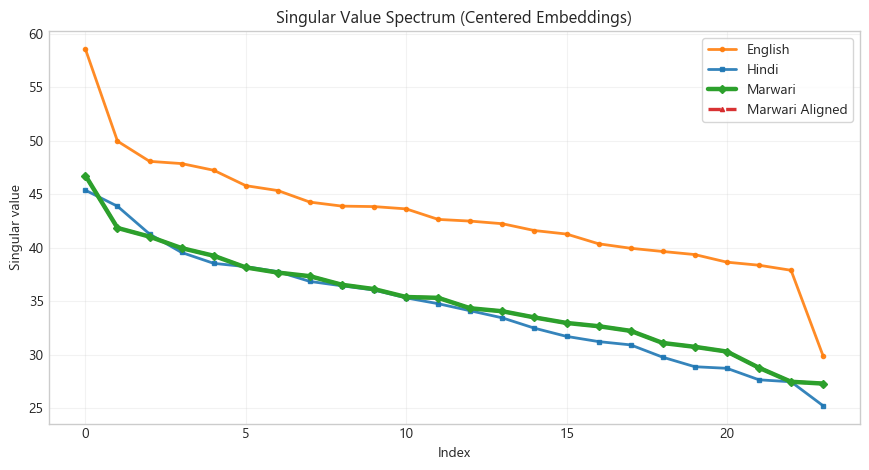

In [52]:
plt.figure(figsize=(8.8, 4.8))

# Use highly distinct colors and styles to avoid visual overlap.
plt.plot(stats_en['singular_values'], label='English', color='#ff7f0e', linewidth=2.0, marker='o', markersize=3, alpha=0.9)
plt.plot(stats_hi['singular_values'], label='Hindi', color='#1f77b4', linewidth=2.0, marker='s', markersize=3, alpha=0.9)
plt.plot(stats_mr['singular_values'], label='Marwari', color='#2ca02c', linewidth=3.2, marker='D', markersize=4, alpha=1.0, zorder=6)
plt.plot(stats_mr_al['singular_values'], label='Marwari Aligned', color='#d62728', linewidth=2.4, linestyle='--', marker='^', markersize=3, alpha=0.95)

plt.title('Singular Value Spectrum (Centered Embeddings)')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.grid(alpha=0.25)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

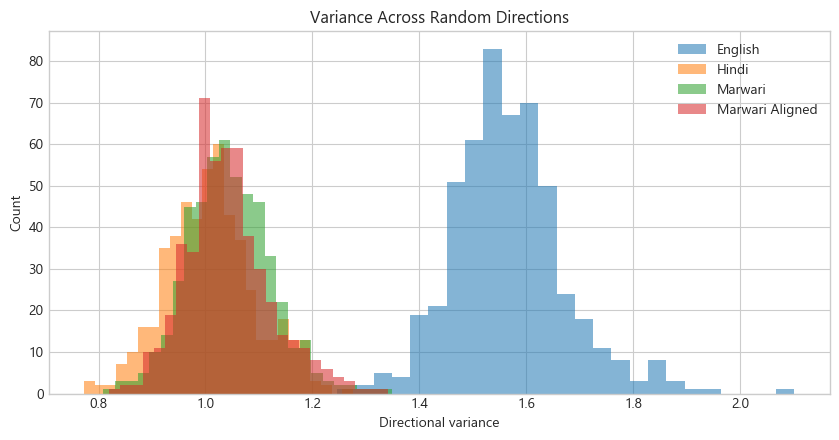

In [53]:
plt.figure(figsize=(8.5, 4.5))
plt.hist(stats_en['directional_variances'], bins=25, alpha=0.55, label='English')
plt.hist(stats_hi['directional_variances'], bins=25, alpha=0.55, label='Hindi')
plt.hist(stats_mr['directional_variances'], bins=25, alpha=0.55, label='Marwari')
plt.hist(stats_mr_al['directional_variances'], bins=25, alpha=0.55, label='Marwari Aligned')
plt.title('Variance Across Random Directions')
plt.xlabel('Directional variance')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Visualization (Marwari-Centric Comparative Geometry)

This section compares **all three spaces** (Marwari, Hindi, English) across multiple geometric views.

Comparison goals:
- Euclidean space structure (PCA, t-SNE)
- Spherical geometry behavior after normalization
- Hyperbolic projection behavior (Poincare)
- Marwari-centered distance contrast against Hindi and English
- Readable cross-lingual similarity heatmaps with focused subsets

In [54]:
def stack_spaces_langdict(lang_spaces):
    X_parts, labels, words = [], [], []
    for lang, (space, vocab) in lang_spaces.items():
        X_parts.append(space)
        labels.extend([lang] * space.shape[0])
        words.extend(vocab)
    X = np.vstack(X_parts)
    return X, labels, words

def reduce_2d(X, method='pca', seed=42):
    if method == 'pca':
        return PCA(n_components=2, random_state=seed).fit_transform(X)
    if method == 'tsne':
        perplexity = max(5, min(20, X.shape[0] // 8))
        return TSNE(n_components=2, random_state=seed, perplexity=perplexity, init='random').fit_transform(X)
    raise ValueError('Unknown method')

def plot_2d_space(coords, labels, words, title, annotate_n=24, seed=42):
    plt.figure(figsize=(8.8, 6.2))
    labels_arr = np.array(labels)
    words_arr = np.array(words)
    palette = {'Marwari': '#d62728', 'Hindi': '#1f77b4', 'English': '#2ca02c'}

    for lang in ['Marwari', 'Hindi', 'English']:
        idx = np.where(labels_arr == lang)[0]
        if len(idx) == 0:
            continue
        plt.scatter(
            coords[idx, 0],
            coords[idx, 1],
            label=lang,
            alpha=0.78,
            s=44,
            c=palette[lang],
            edgecolors='white',
            linewidths=0.35
        )

    # Balanced labeling so English and Hindi words are always visible, not only first language block.
    present_langs = [lang for lang in ['Marwari', 'Hindi', 'English'] if np.any(labels_arr == lang)]
    if present_langs:
        rng = np.random.default_rng(seed)
        per_lang = max(2, annotate_n // len(present_langs))
        ann_idx = []
        for lang in present_langs:
            idx = np.where(labels_arr == lang)[0]
            take = min(per_lang, len(idx))
            choose = rng.choice(idx, size=take, replace=False) if len(idx) > take else idx
            ann_idx.extend(choose.tolist())

        for i in sorted(set(ann_idx)):
            lang = labels_arr[i]
            plt.text(
                coords[i, 0] + 0.02,
                coords[i, 1] + 0.02,
                words_arr[i],
                fontsize=7.5,
                color=palette.get(lang, 'black'),
                alpha=0.95
            )

    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# Precompute coordinates; plots are shown in separate cells
X_euc_all, L_euc_all, W_euc_all = stack_spaces_langdict({
    'Marwari': (mr_emb, mr_vocab),
    'Hindi': (hi_emb, hi_vocab),
    'English': (en_emb, en_vocab),
})
coords_pca_euc_all = reduce_2d(X_euc_all, method='pca')
coords_tsne_euc_all = reduce_2d(X_euc_all, method='tsne')

X_hi_mr, L_hi_mr, W_hi_mr = stack_spaces_langdict({
    'Marwari': (mr_emb_aligned, mr_vocab),
    'Hindi': (hi_emb, hi_vocab),
})
coords_pca_hi_mr = reduce_2d(X_hi_mr, method='pca')

### Embeddings as Geometric Objects

The vector-space arrows below show each embedding as a directed geometric object from the origin in a shared 2D projection.

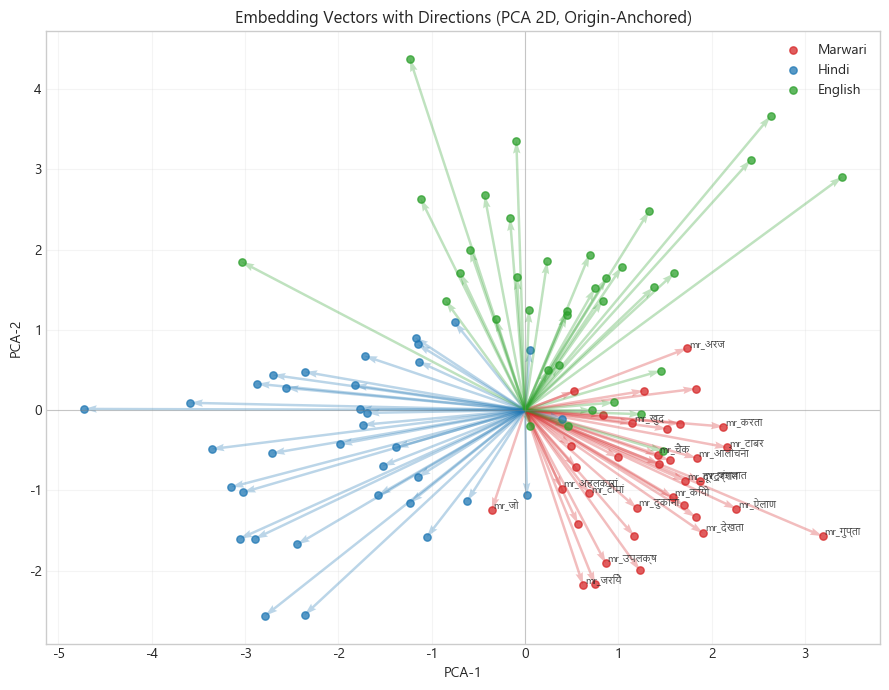

In [55]:
# Directional view in vector space: arrows from origin to 2D PCA embedding coordinates
coords_dir = coords_pca_euc_all
labels_dir = np.array(L_euc_all)
words_dir = W_euc_all

def sample_by_language(labels, max_per_lang=40, seed=42):
    rng = np.random.default_rng(seed)
    idx_out = []
    for lang in np.unique(labels):
        idx = np.where(labels == lang)[0]
        if len(idx) > max_per_lang:
            idx = rng.choice(idx, size=max_per_lang, replace=False)
        idx_out.extend(idx.tolist())
    return np.array(sorted(idx_out), dtype=np.int32)

sample_idx = sample_by_language(labels_dir, max_per_lang=35, seed=42)
palette = {'Marwari': '#d62728', 'Hindi': '#1f77b4', 'English': '#2ca02c'}

plt.figure(figsize=(9.0, 7.0))
for lang in ['Marwari', 'Hindi', 'English']:
    lang_idx = sample_idx[labels_dir[sample_idx] == lang]
    if len(lang_idx) == 0:
        continue
    x = coords_dir[lang_idx, 0]
    y = coords_dir[lang_idx, 1]
    plt.quiver(
        np.zeros_like(x),
        np.zeros_like(y),
        x,
        y,
        angles='xy',
        scale_units='xy',
        scale=1,
        color=palette[lang],
        alpha=0.30,
        width=0.003
    )
    plt.scatter(x, y, s=28, color=palette[lang], alpha=0.75, label=lang)

# Annotate a small subset for readability
ann_idx = sample_idx[:18]
for i in ann_idx:
    plt.text(coords_dir[i, 0] + 0.02, coords_dir[i, 1] + 0.02, words_dir[i], fontsize=7, alpha=0.85)

plt.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
plt.axvline(0, color='gray', linewidth=0.8, alpha=0.4)
plt.title('Embedding Vectors with Directions (PCA 2D, Origin-Anchored)')
plt.xlabel('PCA-1')
plt.ylabel('PCA-2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Isotropy vs. Anisotropy in Embedding Spaces

The next two plots isolate isotropy-dominant and anisotropy-dominant components of each language space.

In [75]:
# Decompose each language space into isotropy-dominant and anisotropy-dominant components
def isotropy_anisotropy_decompose(E, top_k=3):
    Ec = E - E.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(Ec, full_matrices=False)
    V = Vt.T
    basis = V[:, :top_k]
    anis = Ec @ basis @ basis.T
    iso = Ec - anis
    return iso, anis

iso_mr, anis_mr = isotropy_anisotropy_decompose(mr_emb_aligned, top_k=3)
iso_hi, anis_hi = isotropy_anisotropy_decompose(hi_emb, top_k=3)
iso_en, anis_en = isotropy_anisotropy_decompose(en_emb, top_k=3)

X_iso, L_iso, W_iso = stack_spaces_langdict({
    'Marwari': (iso_mr, mr_vocab),
    'Hindi': (iso_hi, hi_vocab),
    'English': (iso_en, en_vocab),
})
coords_iso = reduce_2d(X_iso, method='pca')

X_anis, L_anis, W_anis = stack_spaces_langdict({
    'Marwari': (anis_mr, mr_vocab),
    'Hindi': (anis_hi, hi_vocab),
    'English': (anis_en, en_vocab),
})
coords_anis = reduce_2d(X_anis, method='pca')

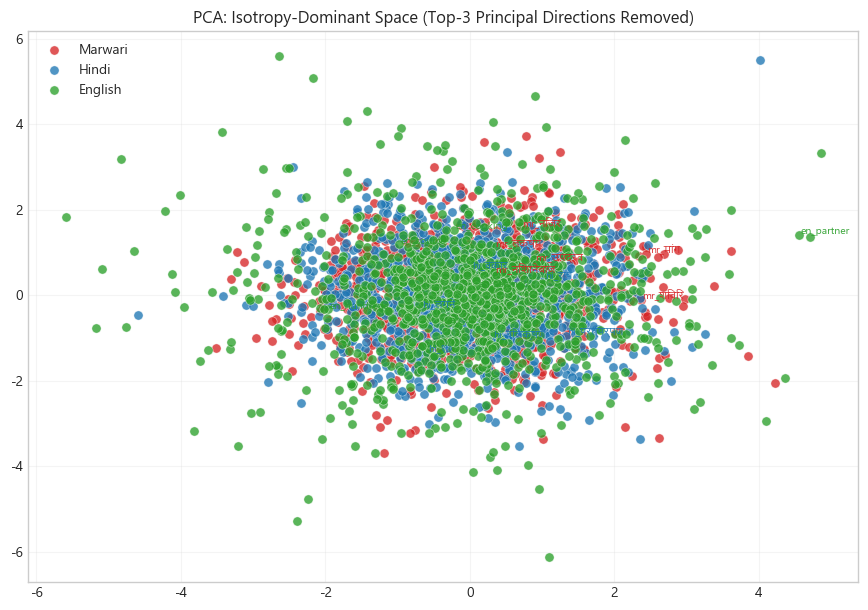

In [57]:
plot_2d_space(
    coords_iso,
    L_iso,
    W_iso,
    'PCA: Isotropy-Dominant Space (Top-3 Principal Directions Removed)',
    annotate_n=18
)

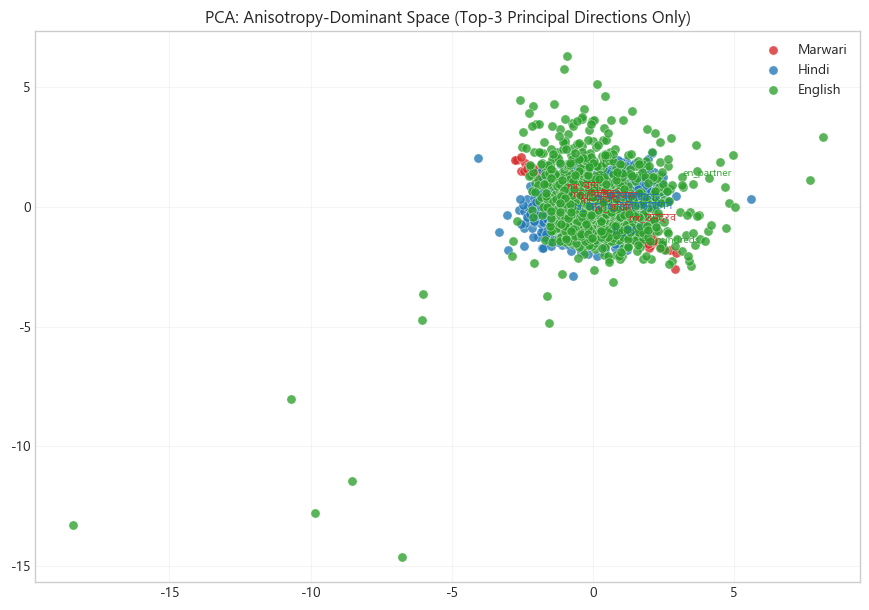

In [58]:
plot_2d_space(
    coords_anis,
    L_anis,
    W_anis,
    'PCA: Anisotropy-Dominant Space (Top-3 Principal Directions Only)',
    annotate_n=18
)

### 3D Directional View: Isotropy vs Anisotropy

This 3D diagnostic projects embeddings into PCA space and overlays principal-direction arrows.

- **Left (isotropy-dominant)**: residual space after removing top principal directions
- **Right (anisotropy-dominant)**: dominant subspace that captures directional concentration

Long, aligned arrows and tighter structure indicate stronger anisotropy; more diffuse spread indicates isotropy.

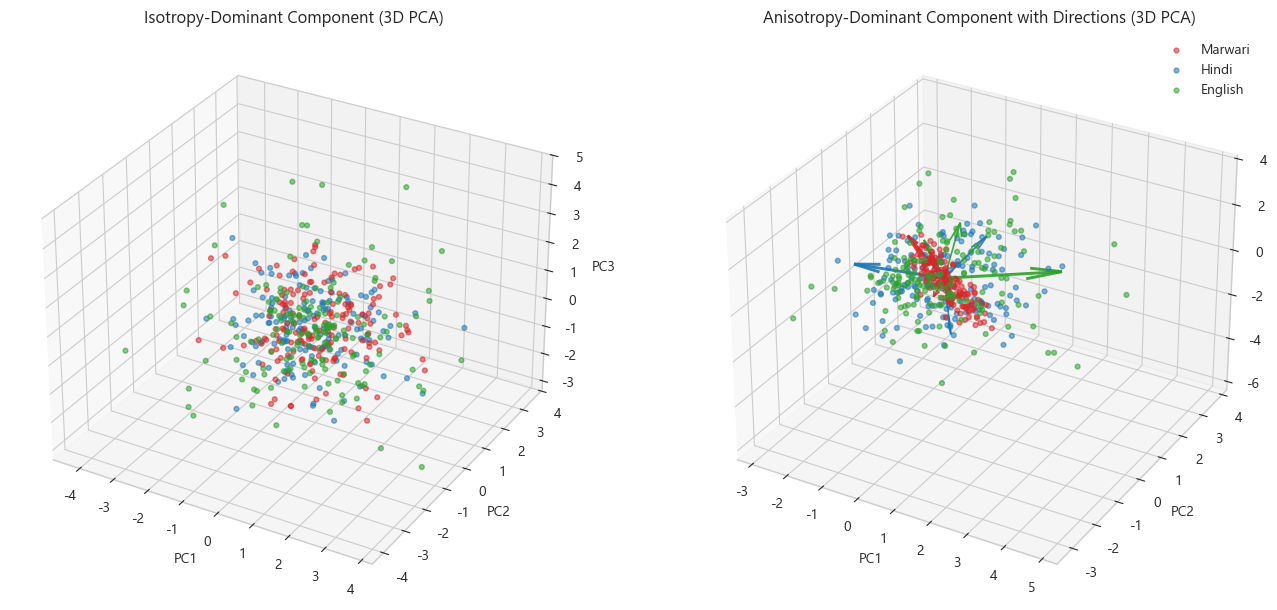

In [76]:
# 3D directional diagnostic: compare isotropy-dominant vs anisotropy-dominant components
def sample_indices_by_lang(labels, max_per_lang=180, seed=42):
    rng = np.random.default_rng(seed)
    labels = np.array(labels)
    out = []
    for lang in ['Marwari', 'Hindi', 'English']:
        idx = np.where(labels == lang)[0]
        if len(idx) == 0:
            continue
        take = min(max_per_lang, len(idx))
        if len(idx) > take:
            idx = rng.choice(idx, size=take, replace=False)
        out.extend(idx.tolist())
    return np.array(sorted(set(out)), dtype=np.int32)

def principal_direction_vectors(E, top_k=3):
    Ec = E - E.mean(axis=0, keepdims=True)
    _, svals, Vt = np.linalg.svd(Ec, full_matrices=False)
    dirs = Vt[:top_k]
    # Scale arrows by explained strength for visual comparability
    strengths = svals[:top_k] / (svals[0] + EPS)
    return dirs, strengths

# Build language-wise spaces for isotropy/anisotropy components
lang_iso = {'Marwari': iso_mr, 'Hindi': iso_hi, 'English': iso_en}
lang_anis = {'Marwari': anis_mr, 'Hindi': anis_hi, 'English': anis_en}
palette = {'Marwari': '#d62728', 'Hindi': '#1f77b4', 'English': '#2ca02c'}

X_iso_all, L_iso_all, _ = stack_spaces_langdict({
    'Marwari': (iso_mr, mr_vocab),
    'Hindi': (iso_hi, hi_vocab),
    'English': (iso_en, en_vocab),
})
X_anis_all, L_anis_all, _ = stack_spaces_langdict({
    'Marwari': (anis_mr, mr_vocab),
    'Hindi': (anis_hi, hi_vocab),
    'English': (anis_en, en_vocab),
})

pca_iso_3d = PCA(n_components=3, random_state=42).fit(X_iso_all)
pca_anis_3d = PCA(n_components=3, random_state=42).fit(X_anis_all)
Z_iso = pca_iso_3d.transform(X_iso_all)
Z_anis = pca_anis_3d.transform(X_anis_all)

idx_iso = sample_indices_by_lang(L_iso_all, max_per_lang=160, seed=42)
idx_anis = sample_indices_by_lang(L_anis_all, max_per_lang=160, seed=42)

fig = plt.figure(figsize=(14, 6.2))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for lang in ['Marwari', 'Hindi', 'English']:
    labels_iso = np.array(L_iso_all)
    labels_anis = np.array(L_anis_all)

    lang_iso_idx = idx_iso[labels_iso[idx_iso] == lang]
    if len(lang_iso_idx):
        ax1.scatter(
            Z_iso[lang_iso_idx, 0], Z_iso[lang_iso_idx, 1], Z_iso[lang_iso_idx, 2],
            s=12, alpha=0.55, color=palette[lang], label=lang
        )

    lang_anis_idx = idx_anis[labels_anis[idx_anis] == lang]
    if len(lang_anis_idx):
        ax2.scatter(
            Z_anis[lang_anis_idx, 0], Z_anis[lang_anis_idx, 1], Z_anis[lang_anis_idx, 2],
            s=12, alpha=0.55, color=palette[lang], label=lang
        )

# Overlay top principal direction arrows (per language, anisotropy-only)
for lang in ['Marwari', 'Hindi', 'English']:
    dirs, strengths = principal_direction_vectors(lang_anis[lang], top_k=3)
    dirs_3d = pca_anis_3d.components_ @ dirs.T  # map to plotted 3D coordinates
    for j in range(3):
        v = dirs_3d[:, j]
        scale = 3.0 * float(strengths[j])
        ax2.quiver(
            0, 0, 0,
            v[0] * scale, v[1] * scale, v[2] * scale,
            color=palette[lang], linewidth=2.1 if j == 0 else 1.2, alpha=0.9
        )

ax1.set_title('Isotropy-Dominant Component (3D PCA)')
ax2.set_title('Anisotropy-Dominant Component with Directions (3D PCA)')

for ax in [ax1, ax2]:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.grid(True, alpha=0.2)

# Keep legend compact and non-duplicated
handles, labels = ax2.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax2.legend(uniq.values(), uniq.keys(), loc='upper right')

plt.tight_layout()
plt.show()

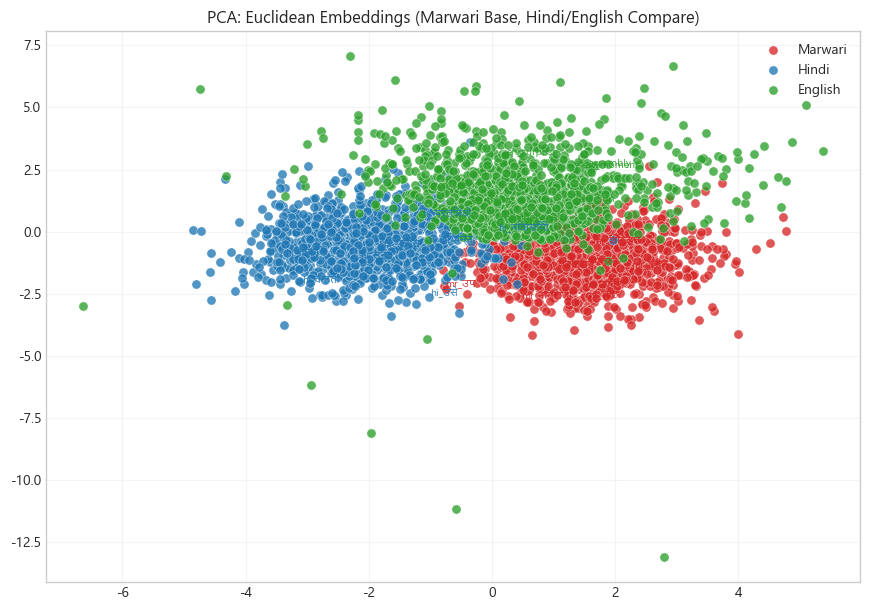

In [59]:
plot_2d_space(
    coords_pca_euc_all,
    L_euc_all,
    W_euc_all,
    'PCA: Euclidean Embeddings (Marwari Base, Hindi/English Compare)'
)

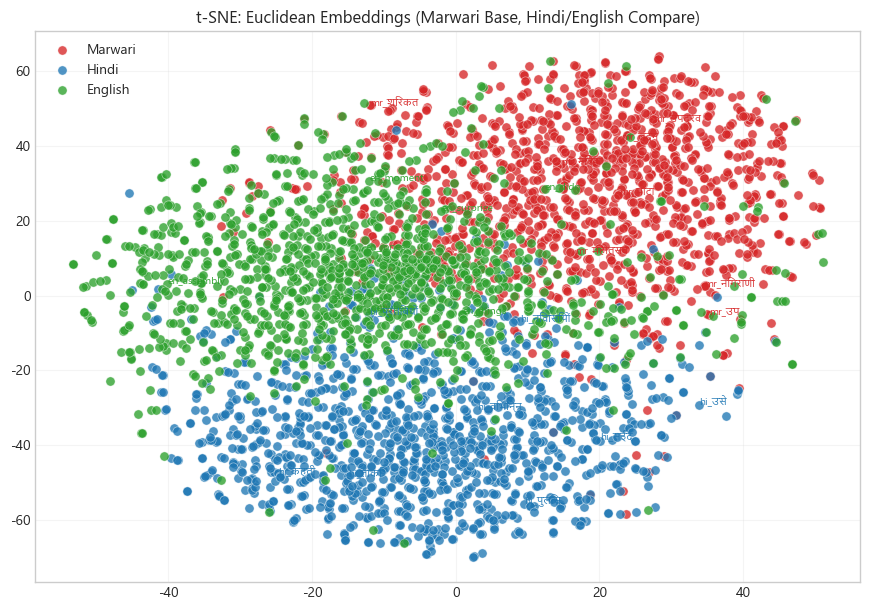

In [60]:
plot_2d_space(
    coords_tsne_euc_all,
    L_euc_all,
    W_euc_all,
    't-SNE: Euclidean Embeddings (Marwari Base, Hindi/English Compare)'
)

### The Manifold Hypothesis

A neighborhood-preservation diagnostic compares how well PCA and t-SNE retain local structure from the original high-dimensional embedding manifold.

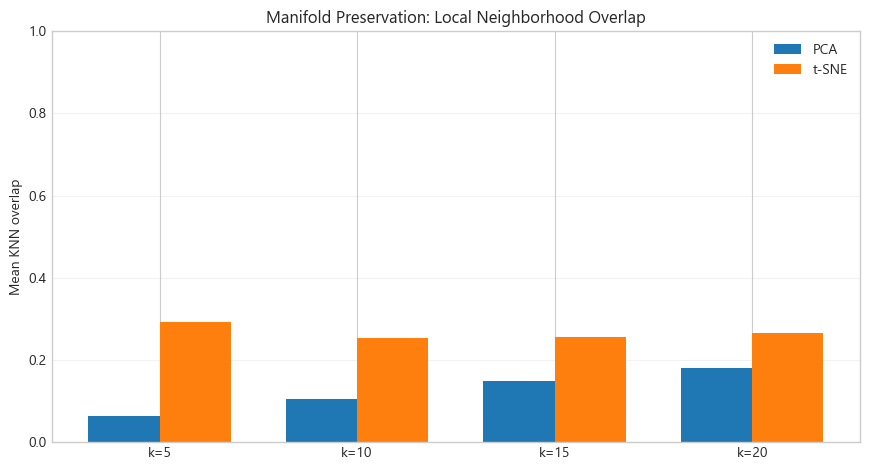

In [61]:
# Neighborhood-overlap diagnostic for manifold structure preservation
def knn_overlap_score(X_high, X_low, k=10):
    n = X_high.shape[0]
    # Squared Euclidean distances via Gram trick for speed
    def pairwise_sqdist(Z):
        g = np.sum(Z * Z, axis=1, keepdims=True)
        D = g + g.T - 2.0 * (Z @ Z.T)
        return np.maximum(D, 0.0)

    Dh = pairwise_sqdist(X_high)
    Dl = pairwise_sqdist(X_low)
    np.fill_diagonal(Dh, np.inf)
    np.fill_diagonal(Dl, np.inf)

    nn_h = np.argsort(Dh, axis=1)[:, :k]
    nn_l = np.argsort(Dl, axis=1)[:, :k]

    overlaps = []
    for i in range(n):
        a = set(nn_h[i].tolist())
        b = set(nn_l[i].tolist())
        overlaps.append(len(a & b) / float(k))
    return float(np.mean(overlaps))

# Keep runtime manageable by random subset
rng = np.random.default_rng(42)
max_n = min(280, X_euc_all.shape[0])
sub_idx = rng.choice(np.arange(X_euc_all.shape[0]), size=max_n, replace=False)
X_high_sub = X_euc_all[sub_idx]

pca_sub = reduce_2d(X_high_sub, method='pca')
tsne_sub = reduce_2d(X_high_sub, method='tsne')

ks = [5, 10, 15, 20]
scores_pca = [knn_overlap_score(X_high_sub, pca_sub, k=k) for k in ks]
scores_tsne = [knn_overlap_score(X_high_sub, tsne_sub, k=k) for k in ks]

x = np.arange(len(ks))
w = 0.36
plt.figure(figsize=(8.8, 4.8))
plt.bar(x - w/2, scores_pca, width=w, label='PCA', color='#1f77b4')
plt.bar(x + w/2, scores_tsne, width=w, label='t-SNE', color='#ff7f0e')
plt.xticks(x, [f'k={k}' for k in ks])
plt.ylim(0, 1.0)
plt.ylabel('Mean KNN overlap')
plt.title('Manifold Preservation: Local Neighborhood Overlap')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

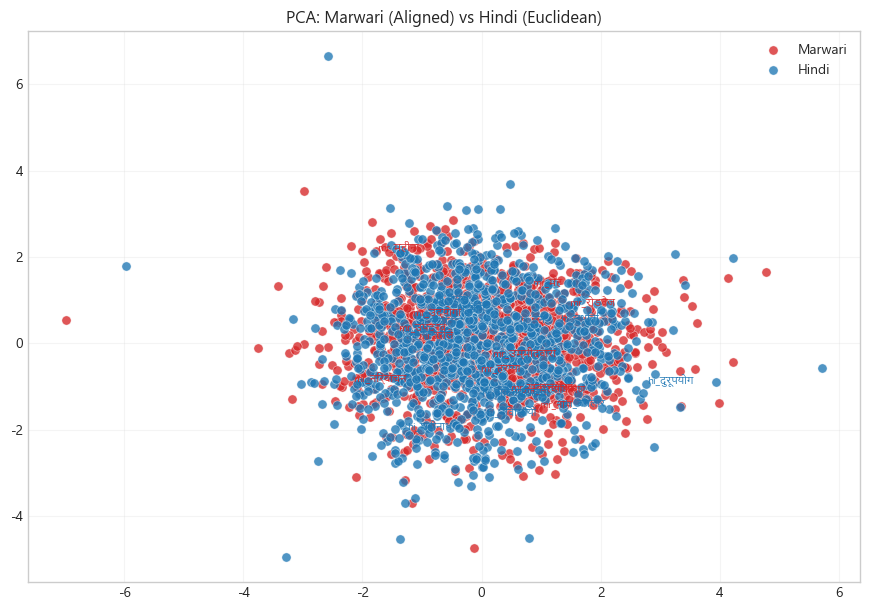

In [62]:
plot_2d_space(
    coords_pca_hi_mr,
    L_hi_mr,
    W_hi_mr,
    'PCA: Marwari (Aligned) vs Hindi (Euclidean)'
)

In [63]:
# Precompute spherical and hyperbolic spaces; each graph is plotted in separate cells
mr_sph_aligned = normalize_rows(mr_emb_aligned)
X_sph, L_sph, W_sph = stack_spaces_langdict({
    'Marwari': (mr_sph_aligned, mr_vocab),
    'Hindi': (hi_sph, hi_vocab),
    'English': (en_sph, en_vocab),
})
coords_pca_sph = reduce_2d(X_sph, method='pca')

hi_hyp = project_to_poincare_ball(hi_emb)
mr_hyp_aligned = project_to_poincare_ball(mr_emb_aligned)
en_hyp = project_to_poincare_ball(en_emb)
X_hyp, L_hyp, W_hyp = stack_spaces_langdict({
    'Marwari': (mr_hyp_aligned, mr_vocab),
    'Hindi': (hi_hyp, hi_vocab),
    'English': (en_hyp, en_vocab),
})
coords_pca_hyp = reduce_2d(X_hyp, method='pca')

def centroid(X):
    return X.mean(axis=0)

geom_spaces = {
    'Euclidean': {'Marwari': mr_emb_aligned, 'Hindi': hi_emb, 'English': en_emb},
    'Spherical': {'Marwari': mr_sph_aligned, 'Hindi': hi_sph, 'English': en_sph},
    'HyperbolicProj': {'Marwari': mr_hyp_aligned, 'Hindi': hi_hyp, 'English': en_hyp},
}

rows = []
for gname, gspace in geom_spaces.items():
    c_mr = centroid(gspace['Marwari'])
    c_hi = centroid(gspace['Hindi'])
    c_en = centroid(gspace['English'])
    rows.append({
        'geometry': gname,
        'd(Marwari,Hindi)': euclidean_distance(c_mr, c_hi),
        'd(Marwari,English)': euclidean_distance(c_mr, c_en),
        'd(Hindi,English)': euclidean_distance(c_hi, c_en),
    })

geom_cmp_df = pd.DataFrame(rows)
display(geom_cmp_df)

,geometry,"d(Marwari,Hindi)","d(Marwari,English)","d(Hindi,English)"
0,Euclidean,0.492517,3.284889,3.174893
1,Spherical,0.090120,0.590325,0.573774
2,HyperbolicProj,0.090110,0.588564,0.572090


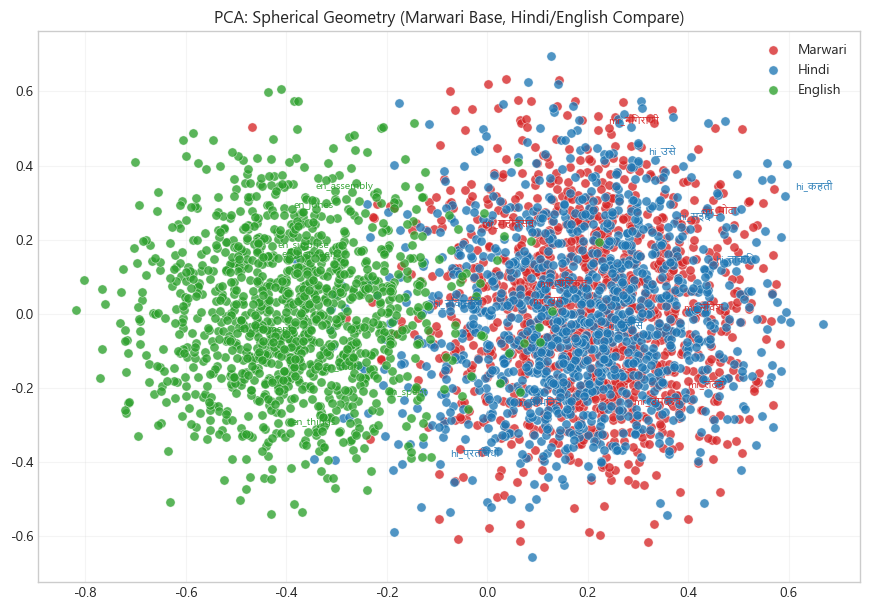

In [64]:
plot_2d_space(
    coords_pca_sph,
    L_sph,
    W_sph,
    'PCA: Spherical Geometry (Marwari Base, Hindi/English Compare)'
)

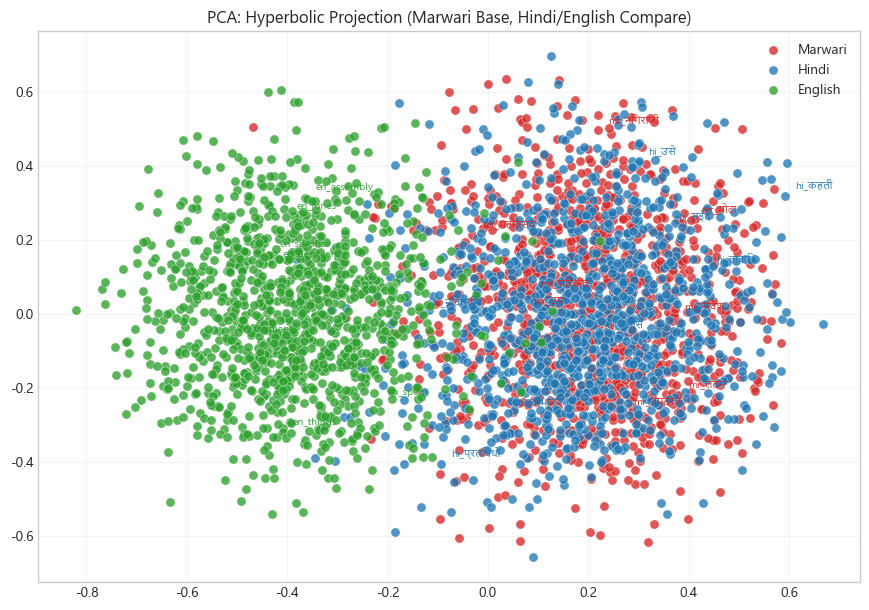

In [65]:
plot_2d_space(
    coords_pca_hyp,
    L_hyp,
    W_hyp,
    'PCA: Hyperbolic Projection (Marwari Base, Hindi/English Compare)'
)

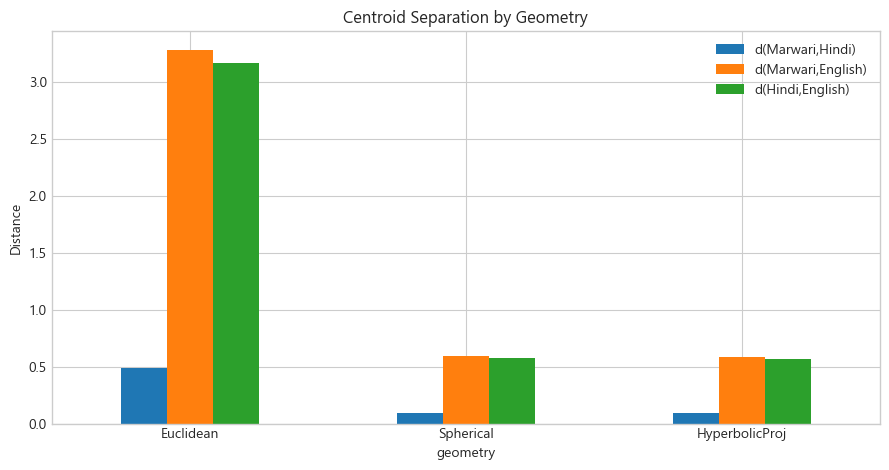

In [66]:
ax = geom_cmp_df.set_index('geometry')[['d(Marwari,Hindi)', 'd(Marwari,English)', 'd(Hindi,English)']].plot(
    kind='bar',
    figsize=(9, 4.8)
)
ax.set_title('Centroid Separation by Geometry')
ax.set_ylabel('Distance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
# Precompute focused Marwari-centered similarity matrices; each heatmap is shown in a separate cell
hi_words = [h for _, h in valid_pairs]
mr_words = [m for m, _ in valid_pairs]

H = np.stack([hi_emb[hi_w2i[w]] for w in hi_words])
M_before = np.stack([mr_emb[mr_w2i[w]] for w in mr_words])
M_after = np.stack([mr_emb_aligned[mr_w2i[w]] for w in mr_words])

S_before = cosine_similarity(M_before, H)
S_after = cosine_similarity(M_after, H)
S_gain = S_after - S_before

diag_gain = np.diag(S_gain)
top_k = min(18, len(mr_words))
top_idx = np.argsort(-diag_gain)[:top_k]

mr_words_top = [mr_words[i] for i in top_idx]
hi_words_top = [hi_words[i] for i in top_idx]
Sb_top = S_before[np.ix_(top_idx, top_idx)]
Sa_top = S_after[np.ix_(top_idx, top_idx)]
Sg_top = S_gain[np.ix_(top_idx, top_idx)]

def draw_heat_single(mat, title, xlabels, ylabels, cmap, vmin=None, vmax=None, fmt='{:.2f}'):
    plt.figure(figsize=(8.6, 7.2))
    im = plt.imshow(mat, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.xticks(range(len(xlabels)), xlabels, rotation=90, fontsize=8)
    plt.yticks(range(len(ylabels)), ylabels, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            color = 'white' if abs(mat[i, j]) > 0.45 else 'black'
            plt.text(j, i, fmt.format(mat[i, j]), ha='center', va='center', fontsize=6, color=color)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

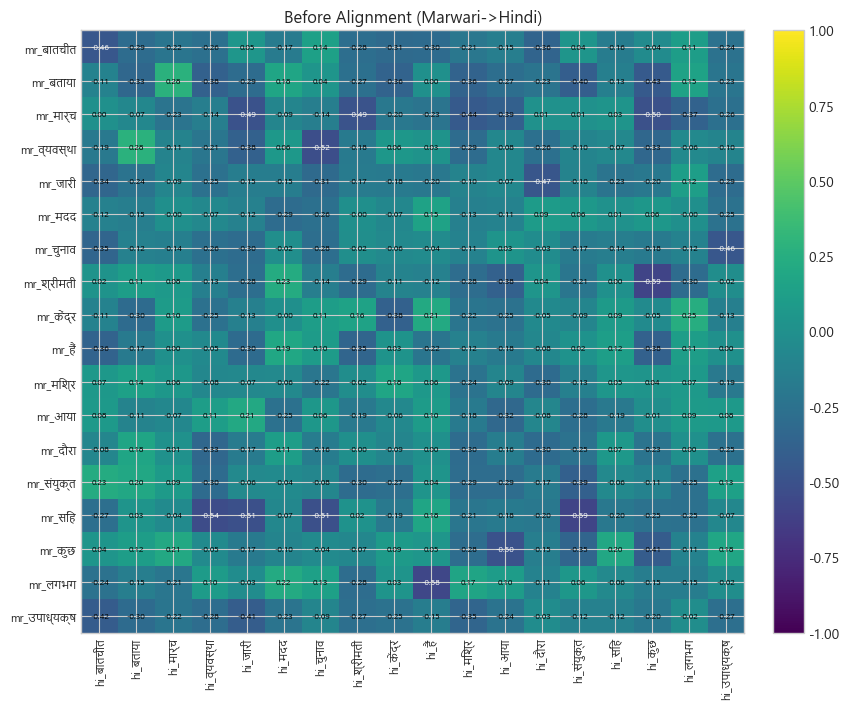

In [68]:
draw_heat_single(
    Sb_top,
    'Before Alignment (Marwari->Hindi)',
    hi_words_top,
    mr_words_top,
    cmap='viridis',
    vmin=-1,
    vmax=1
)

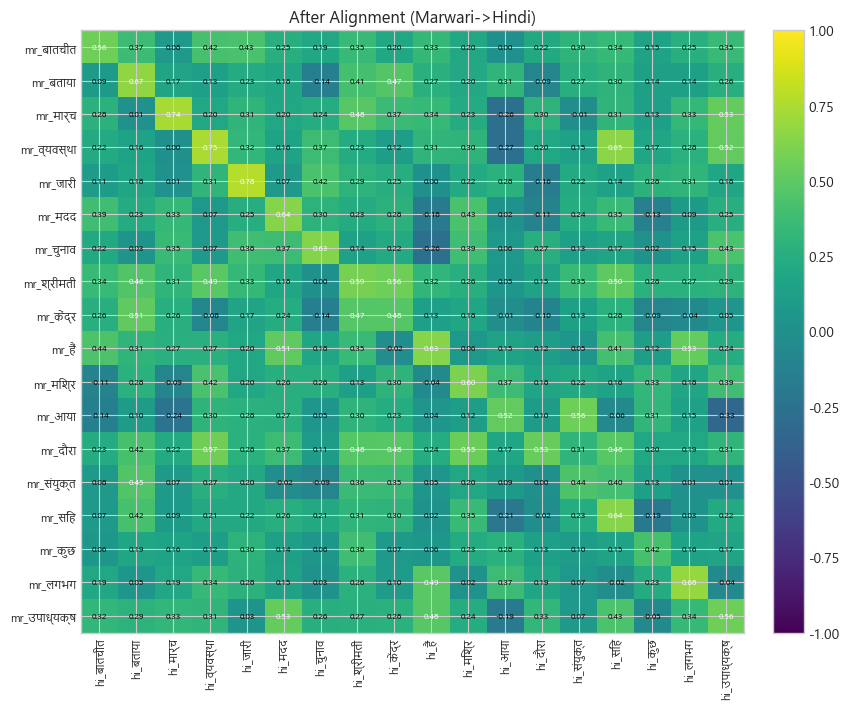

In [69]:
draw_heat_single(
    Sa_top,
    'After Alignment (Marwari->Hindi)',
    hi_words_top,
    mr_words_top,
    cmap='viridis',
    vmin=-1,
    vmax=1
)

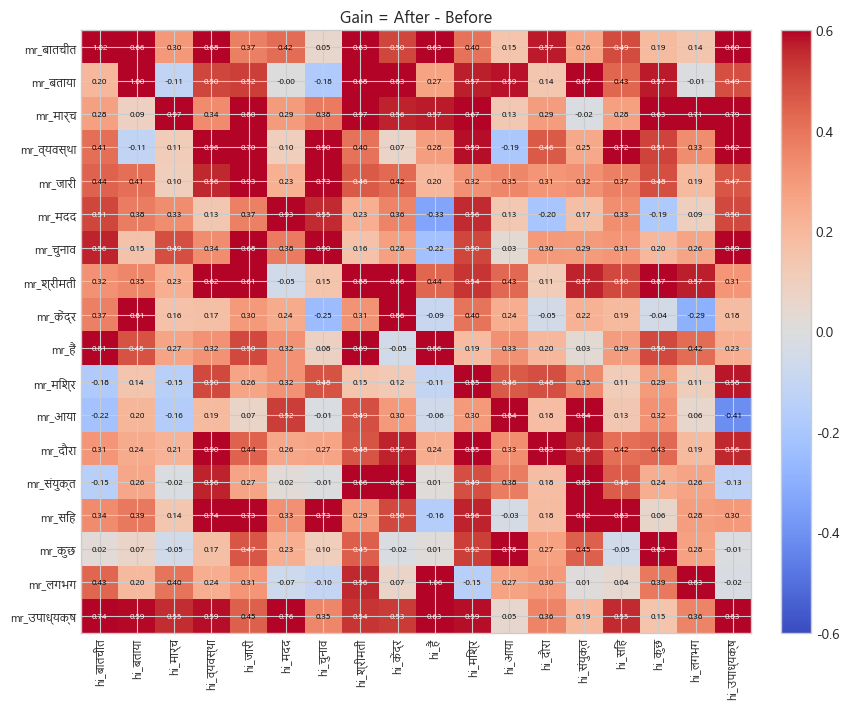

In [70]:
draw_heat_single(
    Sg_top,
    'Gain = After - Before',
    hi_words_top,
    mr_words_top,
    cmap='coolwarm',
    vmin=-0.6,
    vmax=0.6
)

## 11. Experiments and Results

We evaluate:
- Cross-lingual nearest-neighbor retrieval
- Dictionary matching quality under different geometries
- Effect of orthogonal alignment

### Geometry-Aware Multilingual Pipeline

The following flow visual summarizes the geometry-aware training, alignment, and evaluation pipeline used in this notebook.

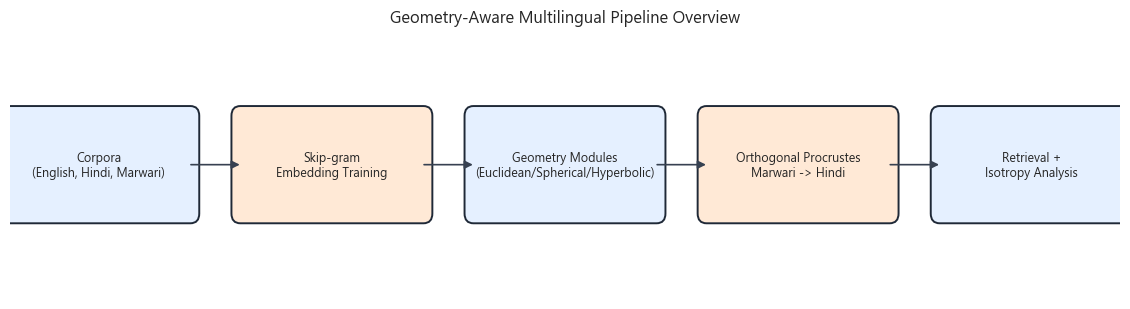

In [71]:
# Compact pipeline flowchart using matplotlib primitives
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    'Corpora\n(English, Hindi, Marwari)',
    'Skip-gram\nEmbedding Training',
    'Geometry Modules\n(Euclidean/Spherical/Hyperbolic)',
    'Orthogonal Procrustes\nMarwari -> Hindi',
    'Retrieval +\nIsotropy Analysis'
 ]

fig, ax = plt.subplots(figsize=(11.4, 3.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2.2)
ax.axis('off')

x_positions = np.linspace(0.8, 9.2, len(steps))
y = 1.1
box_w, box_h = 1.65, 0.8

for i, (x0, text) in enumerate(zip(x_positions, steps)):
    box = FancyBboxPatch(
        (x0 - box_w / 2, y - box_h / 2),
        box_w, box_h,
        boxstyle='round,pad=0.08,rounding_size=0.08',
        linewidth=1.4,
        edgecolor='#1f2937',
        facecolor='#e5f0ff' if i % 2 == 0 else '#ffe9d6'
    )
    ax.add_patch(box)
    ax.text(x0, y, text, ha='center', va='center', fontsize=9)

for i in range(len(x_positions) - 1):
    arr = FancyArrowPatch(
        (x_positions[i] + box_w / 2 - 0.02, y),
        (x_positions[i + 1] - box_w / 2 + 0.02, y),
        arrowstyle='-|>',
        mutation_scale=12,
        linewidth=1.2,
        color='#374151'
    )
    ax.add_patch(arr)

ax.set_title('Geometry-Aware Multilingual Pipeline Overview')
plt.tight_layout()
plt.show()

In [72]:
def nearest_neighbors(query_vec, candidates, candidate_words, topk=5, metric='cosine'):
    scores = []
    for i, vec in enumerate(candidates):
        if metric == 'cosine':
            s = cosine_sim(query_vec, vec)
            scores.append((candidate_words[i], s))
        elif metric == 'euclidean':
            d = euclidean_distance(query_vec, vec)
            scores.append((candidate_words[i], -d))
        elif metric == 'angular':
            d = angular_distance(query_vec, vec)
            scores.append((candidate_words[i], -d))
        else:
            raise ValueError('Unsupported metric')
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return scores[:topk]

# Qualitative cross-lingual retrieval examples (Marwari -> Hindi)
queries = [m for m, _ in valid_pairs[:5]]
for q in queries:
    q_before = mr_emb[mr_w2i[q]]
    q_after = mr_emb_aligned[mr_w2i[q]]

    nn_before = nearest_neighbors(q_before, hi_emb, hi_vocab, topk=3, metric='cosine')
    nn_after = nearest_neighbors(q_after, hi_emb, hi_vocab, topk=3, metric='cosine')

    print(f'Query: {q}')
    print('  Before alignment:', nn_before)
    print('  After alignment :', nn_after)
    print('-' * 80)

# Monolingual nearest-neighbor sanity examples
for lang, emb, vocab, w2i in [('English', en_emb, en_vocab, en_w2i), ('Hindi', hi_emb, hi_vocab, hi_w2i), ('Marwari', mr_emb, mr_vocab, mr_w2i)]:
    q = vocab[min(3, len(vocab)-1)]
    qv = emb[w2i[q]]
    nns = nearest_neighbors(qv, emb, vocab, topk=4, metric='cosine')
    print(f'{lang} monolingual NN for {q}:', nns)

Query: mr_अधिकारी
  Before alignment: [('hi_सहयोग', 0.44563195554183244), ('hi_आवास', 0.371723565932649), ('hi_बाल', 0.37033232155135803)]
  After alignment : [('hi_अहमदाबाद', 0.7395278984698156), ('hi_मंदिर', 0.6937856103264317), ('hi_म्यांमार', 0.6897662246309754)]
--------------------------------------------------------------------------------
Query: mr_अध्यक्ष
  Before alignment: [('hi_निर्यात', 0.3732987650855755), ('hi_योहाना', 0.36733070318331995), ('hi_हज', 0.33410431910998006)]
  After alignment : [('hi_अवधि', 0.685828727775406), ('hi_बार', 0.6489366315150735), ('hi_तथ्य', 0.6488599543054268)]
--------------------------------------------------------------------------------
Query: mr_अमेरिका
  Before alignment: [('hi_डिपुटी', 0.5606365144404122), ('hi_कम्प्यूटर', 0.5375022050659083), ('hi_विधानसभा', 0.4412416606593697)]
  After alignment : [('hi_राज्य', 0.5023435452925479), ('hi_मदद', 0.47337196788000846), ('hi_उसने', 0.47250469093338804)]
--------------------------------------

,metric,before_r1_full,after_r1_full,gain_r1_full,before_r5_full,after_r5_full,gain_r5_full,before_mrr_full,after_mrr_full,gain_mrr_full,before_r1_dict,after_r1_dict,gain_r1_dict,before_r5_dict,after_r5_dict,gain_r5_dict,before_mrr_dict,after_mrr_dict,gain_mrr_dict
0,euclidean,0.0,0.029412,0.029412,0.005882,0.105882,0.100000,0.005649,0.070506,0.064858,0.005882,0.094118,0.088235,0.029412,0.317647,0.288235,0.033883,0.201725,0.167842
1,cosine,0.0,0.052941,0.052941,0.005882,0.158824,0.152941,0.008167,0.110495,0.102328,0.011765,0.135294,0.123529,0.041176,0.335294,0.294118,0.042841,0.246967,0.204125
2,angular,0.0,0.052941,0.052941,0.005882,0.158824,0.152941,0.008167,0.110495,0.102328,0.011765,0.135294,0.123529,0.041176,0.335294,0.294118,0.042841,0.246967,0.204125
3,hyperbolic,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003477,0.005054,0.001577,0.011765,0.005882,-0.005882,0.023529,0.082353,0.058824,0.037376,0.052067,0.014691


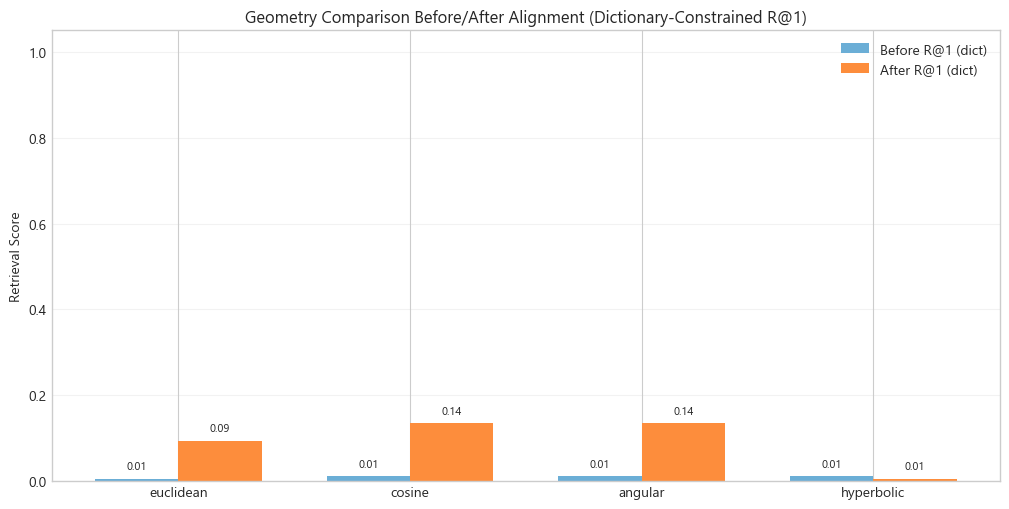

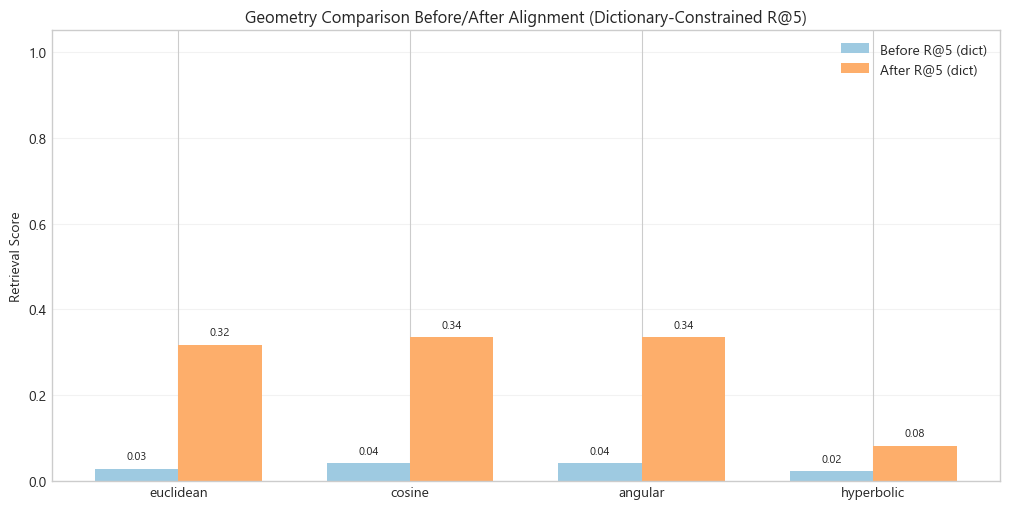

In [73]:
def rank_of_gold(query_vec, gold_tgt, tgt_words, tgt_mat, metric='cosine'):
    if metric == 'cosine':
        vals = np.array([cosine_sim(query_vec, v) for v in tgt_mat])
        order = np.argsort(-vals)
    elif metric == 'euclidean':
        vals = np.array([euclidean_distance(query_vec, v) for v in tgt_mat])
        order = np.argsort(vals)
    elif metric == 'angular':
        vals = np.array([angular_distance(query_vec, v) for v in tgt_mat])
        order = np.argsort(vals)
    elif metric == 'hyperbolic':
        qh = project_to_poincare_ball(query_vec[None, :])[0]
        Th = project_to_poincare_ball(tgt_mat)
        vals = np.array([hyperbolic_distance_poincare(qh, v) for v in Th])
        vals = np.nan_to_num(vals, nan=1e9, posinf=1e9, neginf=1e9)
        order = np.argsort(vals)
    else:
        raise ValueError('Unknown metric')

    ranked_words = [tgt_words[i] for i in order]
    return ranked_words.index(gold_tgt) + 1

def retrieval_metrics(pairs, src_emb, src_w2i, tgt_emb, tgt_w2i, metric='cosine', candidate_mode='full'):
    if candidate_mode == 'full':
        tgt_words = sorted(tgt_w2i.keys())
    elif candidate_mode == 'dict_only':
        tgt_words = sorted({t for _, t in pairs})
    else:
        raise ValueError('candidate_mode must be full or dict_only')

    tgt_mat = np.stack([tgt_emb[tgt_w2i[w]] for w in tgt_words])
    ranks = []
    for src_w, gold_tgt in pairs:
        q = src_emb[src_w2i[src_w]]
        ranks.append(rank_of_gold(q, gold_tgt, tgt_words, tgt_mat, metric=metric))

    ranks = np.array(ranks)
    r1 = float(np.mean(ranks <= 1))
    r5 = float(np.mean(ranks <= 5))
    mrr = float(np.mean(1.0 / ranks))
    return r1, r5, mrr

metrics = ['euclidean', 'cosine', 'angular', 'hyperbolic']
results = []

for m in metrics:
    b_full_r1, b_full_r5, b_full_mrr = retrieval_metrics(valid_pairs, mr_emb, mr_w2i, hi_emb, hi_w2i, metric=m, candidate_mode='full')
    a_full_r1, a_full_r5, a_full_mrr = retrieval_metrics(valid_pairs, mr_emb_aligned, mr_w2i, hi_emb, hi_w2i, metric=m, candidate_mode='full')

    b_dic_r1, b_dic_r5, b_dic_mrr = retrieval_metrics(valid_pairs, mr_emb, mr_w2i, hi_emb, hi_w2i, metric=m, candidate_mode='dict_only')
    a_dic_r1, a_dic_r5, a_dic_mrr = retrieval_metrics(valid_pairs, mr_emb_aligned, mr_w2i, hi_emb, hi_w2i, metric=m, candidate_mode='dict_only')

    results.append({
        'metric': m,
        'before_r1_full': b_full_r1, 'after_r1_full': a_full_r1, 'gain_r1_full': a_full_r1 - b_full_r1,
        'before_r5_full': b_full_r5, 'after_r5_full': a_full_r5, 'gain_r5_full': a_full_r5 - b_full_r5,
        'before_mrr_full': b_full_mrr, 'after_mrr_full': a_full_mrr, 'gain_mrr_full': a_full_mrr - b_full_mrr,
        'before_r1_dict': b_dic_r1, 'after_r1_dict': a_dic_r1, 'gain_r1_dict': a_dic_r1 - b_dic_r1,
        'before_r5_dict': b_dic_r5, 'after_r5_dict': a_dic_r5, 'gain_r5_dict': a_dic_r5 - b_dic_r5,
        'before_mrr_dict': b_dic_mrr, 'after_mrr_dict': a_dic_mrr, 'gain_mrr_dict': a_dic_mrr - b_dic_mrr,
    })

res_df = pd.DataFrame(results)
display(res_df)

# Main chart now uses dictionary-constrained R@1 and R@5 for clearer before/after interpretation.
x = np.arange(len(res_df))
w = 0.36

plt.figure(figsize=(10.2, 5.2))
b1 = plt.bar(x - w/2, res_df['before_r1_dict'], width=w, color='#6baed6', label='Before R@1 (dict)')
b2 = plt.bar(x + w/2, res_df['after_r1_dict'], width=w, color='#fd8d3c', label='After R@1 (dict)')

plt.xticks(x, res_df['metric'])
plt.ylim(0, 1.05)
plt.ylabel('Retrieval Score')
plt.title('Geometry Comparison Before/After Alignment (Dictionary-Constrained R@1)')
plt.legend()
plt.grid(axis='y', alpha=0.25)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10.2, 5.2))
b3 = plt.bar(x - w/2, res_df['before_r5_dict'], width=w, color='#9ecae1', label='Before R@5 (dict)')
b4 = plt.bar(x + w/2, res_df['after_r5_dict'], width=w, color='#fdae6b', label='After R@5 (dict)')

plt.xticks(x, res_df['metric'])
plt.ylim(0, 1.05)
plt.ylabel('Retrieval Score')
plt.title('Geometry Comparison Before/After Alignment (Dictionary-Constrained R@5)')
plt.legend()
plt.grid(axis='y', alpha=0.25)

for bars in [b3, b4]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Geometry-Aware Embeddings Improve Low-Resource NLP

This summary visual highlights metric gains after alignment and geometry-aware processing in the low-resource Marwari -> Hindi setting.

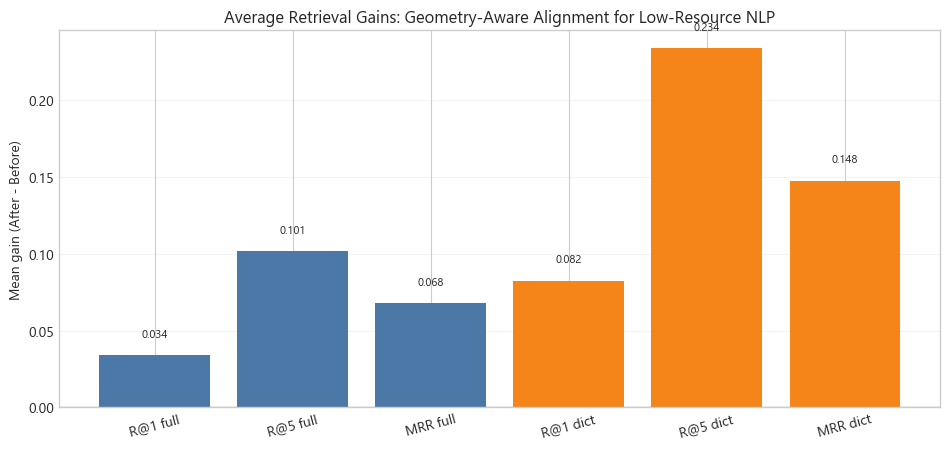

In [74]:
# Aggregate improvement summary across metrics
gain_cols = ['gain_r1_full', 'gain_r5_full', 'gain_mrr_full', 'gain_r1_dict', 'gain_r5_dict', 'gain_mrr_dict']
mean_gains = {c: float(res_df[c].mean()) for c in gain_cols}

labels = ['R@1 full', 'R@5 full', 'MRR full', 'R@1 dict', 'R@5 dict', 'MRR dict']
vals = [
    mean_gains['gain_r1_full'],
    mean_gains['gain_r5_full'],
    mean_gains['gain_mrr_full'],
    mean_gains['gain_r1_dict'],
    mean_gains['gain_r5_dict'],
    mean_gains['gain_mrr_dict'],
]

plt.figure(figsize=(9.6, 4.6))
bars = plt.bar(labels, vals, color=['#4c78a8', '#4c78a8', '#4c78a8', '#f58518', '#f58518', '#f58518'])
plt.axhline(0, color='gray', linewidth=0.9)
plt.ylabel('Mean gain (After - Before)')
plt.title('Average Retrieval Gains: Geometry-Aware Alignment for Low-Resource NLP')
plt.grid(axis='y', alpha=0.22)
plt.xticks(rotation=15)

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, h + (0.01 if h >= 0 else -0.02), f'{h:.3f}', ha='center', va='bottom' if h >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

### Result Discussion

Interpretation template (run after results):
- Alignment should generally increase cross-lingual cosine consistency.
- Spherical view reduces norm effects and stabilizes angular neighborhoods.
- Hyperbolic distance often better reflects hierarchical toy structures than flat Euclidean distance.
- Anisotropy indicators reveal whether embeddings are dominated by few principal directions.

## 12. Conclusion and Insights

This notebook demonstrates a compact research pipeline for multilingual low-resource representation geometry:

1. **Theory to implementation**: Euclidean, spherical, and hyperbolic metrics were formalized and coded in one workflow.
2. **Cross-lingual alignment**: Orthogonal Procrustes effectively maps Marwari vectors into Hindi space while preserving geometric structure.
3. **Anisotropy diagnosis**: Singular spectra and directional variance provide practical evidence about embedding quality and directional collapse.
4. **Non-Euclidean value**: Spherical geometry supports angular semantic comparisons; hyperbolic geometry better models hierarchy due to negative curvature and exponential capacity.

For low-resource languages such as Marwari, geometry-aware methods can improve robustness even with small corpora, and provide a mathematically interpretable path toward multilingual transfer.